# Power Based Channel Attacks 

Hello and welcome to our course about Side Channel Attacks using the teem emulator. While we will delve into multiple different attacks, we will begin by explaining the power model of our emulator and show you the basic statistical properties that are gonna be exploited by these attacks. 

## Setup 

First lets begin by making sure that the required depdendencies for running  the emulator as well as this notebook are installed. To do this please execute the codeblock below.

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
#from benedict import benedict 
import prompt_toolkit

If you got an error when running the code cell above, please make sure to install the required dependencies into your python kernel. 

Now lets continue. The folder of this course contains a directory called traces, with a file called "example-traces.npy". This file contains 256 different sample traces from an AES encryption algorithm, more specifically the SubBytes stage of the algorithm. In power based side channel attacks on the AES algorithm this is the most common point of attack. The traces also only include the measurements of the cpu cycles which executed the following operation

```python
data[0] = sbox[clear_text[0] ^ key[0]]
```

Furthermore the recording contains only traces from the very first round of the AES run, because that is all that is required to break aes.
Next we will load the data and present you with two graphics which will demonstrate the differences we will abuse in our attack.

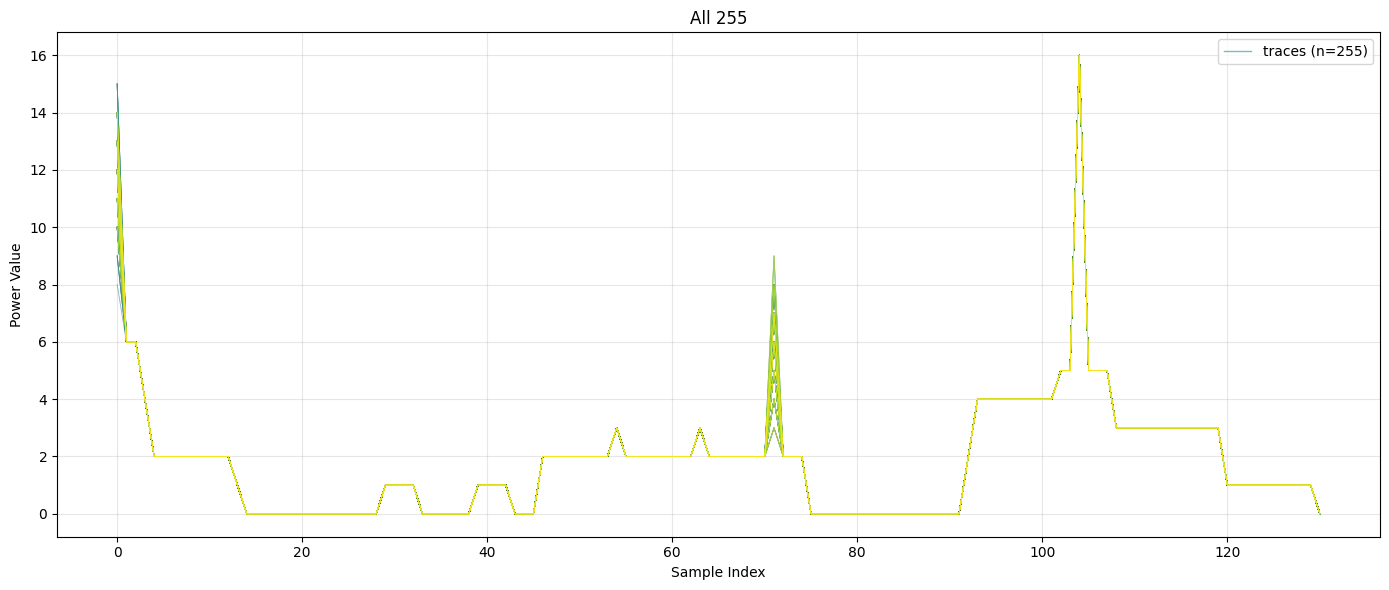

In [2]:
trace_data = np.load("traces/example-traces.npy")

min_len = min([len(n) for n in trace_data])
mean_trace = np.mean(trace_data, axis=0)

colors = cm.viridis(np.linspace(0, 1, len(trace_data)))
fig, ax = plt.subplots(figsize=(14, 6))

for i, data in enumerate(trace_data):
    ax.plot(data[:min_len], color = colors[i], alpha=0.3, linewidth=0.6)
ax.set_title(f"All {len(trace_data)}")
ax.set_ylabel("Power Value")

trace_proxy = Line2D([0], [0], color=cm.viridis(0.5), alpha=0.6, linewidth=1,
                     label=f"traces (n={len(trace_data)})")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[trace_proxy] + handles, labels=[trace_proxy.get_label()] + labels)
ax.set_xlabel("Sample Index")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


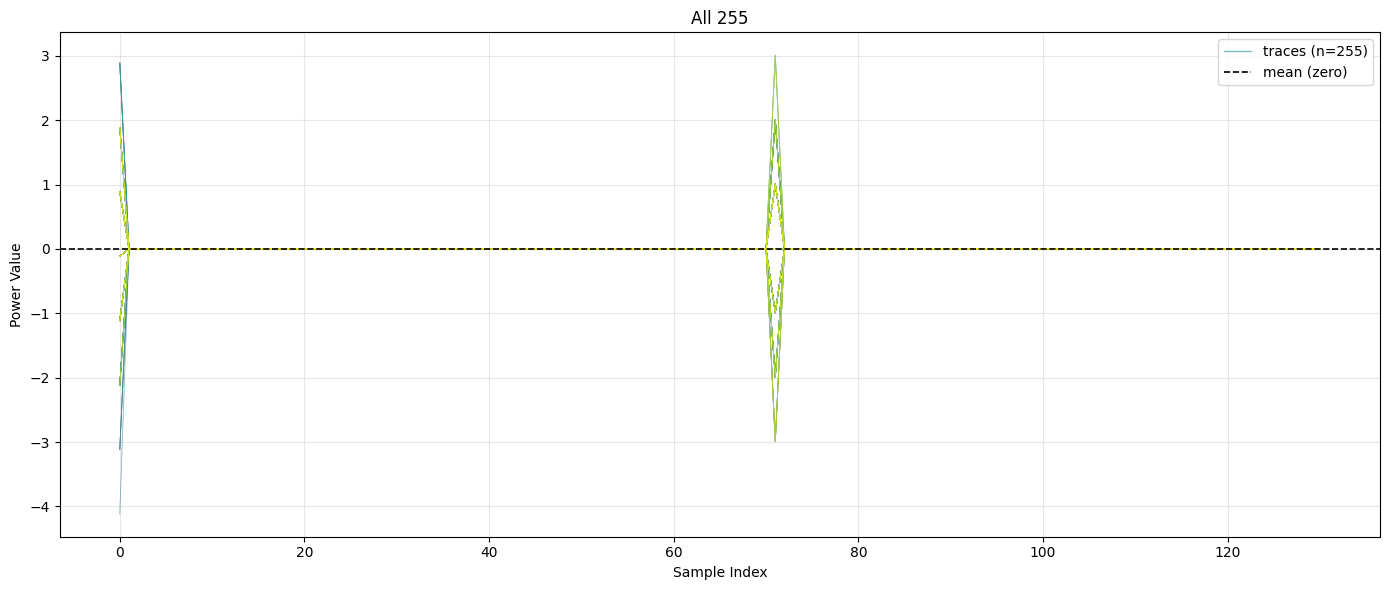

In [6]:
colors = cm.viridis(np.linspace(0, 1, len(trace_data)))
fig, ax = plt.subplots(figsize=(14, 6))

for i, data in enumerate(trace_data):
      ax.plot(data - mean_trace, color=colors[i], alpha=0.3, linewidth=0.6)
ax.axhline(0, color="black", linewidth=1.2, linestyle="--", label="mean (zero)")
ax.set_title(f"All {len(trace_data)} Power Traces — Difference from Mean")
ax.set_ylabel("Power Value − Mean")

ax.set_title(f"All {len(trace_data)}")
ax.set_ylabel("Power Value")

trace_proxy = Line2D([0], [0], color=cm.viridis(0.5), alpha=0.6, linewidth=1,
                     label=f"traces (n={len(trace_data)})")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=[trace_proxy] + handles, labels=[trace_proxy.get_label()] + labels)
ax.set_xlabel("Sample Index")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()